In [25]:
from astropy.table import Table, vstack
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

In [5]:
indices = np.arange(0, 641410+5831, 5831)

In [3]:
DATA_FOLDER = '/pscratch/sd/n/nravi/GV_classification/'

In [ ]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_' + str(indices[0]) + '_' + str(indices[1]) +'.fits')
for i in range(1, len(indices)-1):
    add_table = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_' + str(indices[i]) + '_' + str(indices[i+1]) + '.fits')
    nsa = vstack([nsa, add_table])

In [15]:
nsa.write(DATA_FOLDER + 'nsa_v1_0_1_cd.fits', overwrite=True)

## compare with kias values

In [4]:
kias = Table.read(DATA_FOLDER + 'NSA_v1_0_1_vflag_Portsmouth.fits')

In [5]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd.fits')

In [6]:
nsa_dict = {}
for i in range(len(nsa)):

    nsa_dict[nsa['IAUNAME'][i]] = i

In [7]:
nsa['kias_cd'] = np.ones(len(nsa))**np.nan

In [12]:
for i in tqdm.tqdm(range(len(kias))):

    iauname = kias['IAUNAME'][i]
    i_nsa = nsa_dict[iauname]

    nsa['kias_cd'][i_nsa] = kias['cd'][i]

100%|██████████| 641409/641409 [00:02<00:00, 290849.42it/s]


Text(0, 0.5, 'KIAS $\\Delta (g-i)$')

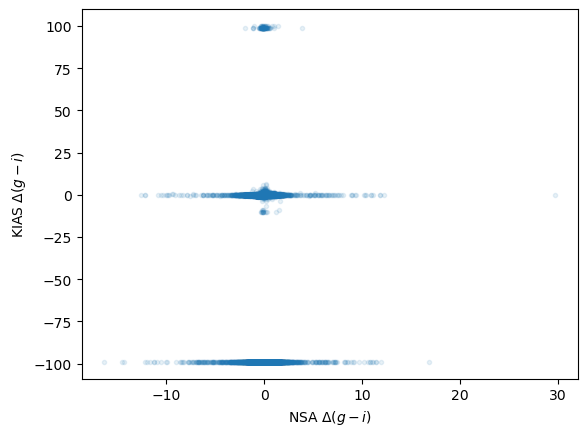

In [30]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.1, marker='.', )
           # bins=100, 
           #range=[[-1, 1], [-5, 5]], 
           # norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')

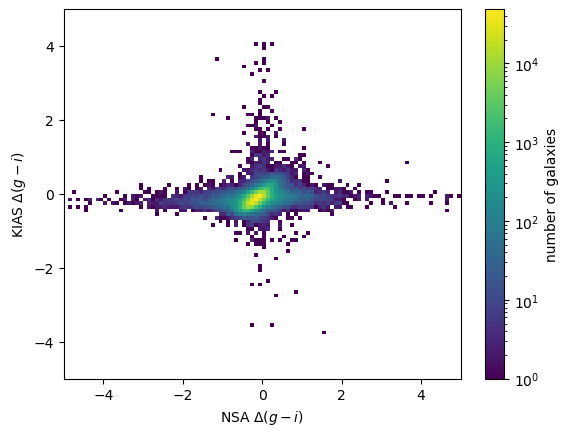

In [37]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-5, 5], [-5, 5]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

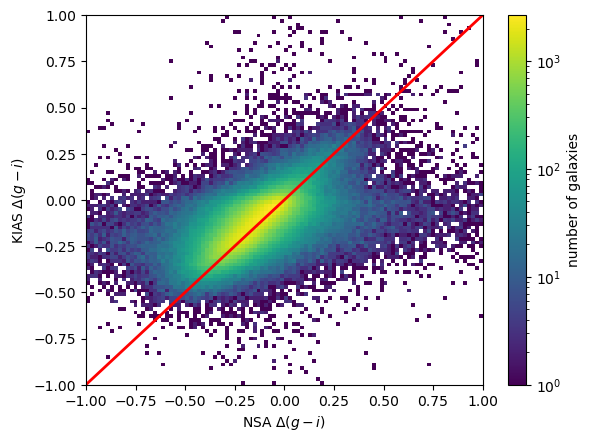

In [39]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-1, 1], [-1, 1]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')